# Grupo 5 — Holt-Winters

### Estado desta análise

Configuração oficial do Grupo 5: **granularidade semanal (W-FRI, sextas-feiras)**, **treino 75% / teste 25%** (divisão cronológica, sem embaralhar), **seed 42**, previsão de **13 passos (13 semanas = 1 trimestre)** com validação **walk-forward** de janela expansiva (46 origens, que cobrem todo o período de teste).

A fonte é o Excel tratado do Grupo 5 (`dados_tratados/base-tratada-5.xlsx`), selecionado por `BASE_NAME = 'base-tratada-5'` e resolvido para a chave do manifesto (`ouro`). **Não há agregação neste notebook**: a série é semanal do começo ao fim.

**Diferenças em relação ao notebook base (grupo 1):** `FREQUENCY='W-FRI'`, `SEED=42`, `TRAIN_FRAC=0.75`, alvo `VALUE`; série semanal sem NaN; horizonte de 13 semanas (trimestre) e horizonte longo de 52 semanas (1 ano).

**Ordem de execução (sempre `Restart & Run All`):** importações → configuração global → configuração do Holt-Winters → carga → T04/T05 (sazonalidade) → T08 (walk-forward) → T09 (modelagem) → T16 (comparação por MAE) → T17 (resíduos) → conclusões.


## Importações e Configurações Padrão

In [1]:
import itertools
import json
import math
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller

warnings.filterwarnings('ignore')

## Configuração global

In [2]:
BASE_NAME = 'base-tratada-5'
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'preparacao_bases.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from preparacao_bases import carregar_base_tratada   # o sys.path precisa estar pronto ANTES deste import

DATA_FILENAME = f'{BASE_NAME}.xlsx'
TARGET_COLUMN = 'VALUE'

FREQUENCY = 'W-FRI'   # granularidade semanal (W-FRI) (metadados.frequencia = 'W-FRI')
FMT_DATA = '%Y-%m-%d'     # formato de data/hora nas tabelas de folds
SEED = 42
TRAIN_FRAC = 0.75    # treino 75% / teste 25%, divisão cronológica (sem embaralhar)
TEST_FRAC = round(1 - TRAIN_FRAC, 2)

random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)   # use RNG.* em simulações/bootstrap

# O manifesto indexa as bases pelo nome lógico (bitcoin, trafego, poluicao, clima, ouro).
_manifesto = json.loads((PROJECT_ROOT / 'dados_tratados' / 'manifesto.json').read_text(encoding='utf-8'))
BASE_KEY = next((nome for nome, item in _manifesto['bases'].items()
                 if item['excel'] == DATA_FILENAME), None)
assert BASE_KEY, f'Excel {DATA_FILENAME} não encontrado no manifesto.'

# Valida os parâmetros contra os metadados gravados na própria planilha
_meta = (pd.read_excel(PROJECT_ROOT / 'dados_tratados' / DATA_FILENAME, sheet_name='metadados')
           .set_index('campo')['valor'])
assert str(_meta['frequencia']) == FREQUENCY, f"Frequência da base: {_meta['frequencia']}"
assert int(_meta['seed']) == SEED, f"Seed da base: {_meta['seed']}"
assert math.isclose(float(_meta['treino']), TRAIN_FRAC), f"Treino da base: {_meta['treino']}"

print(f'Fonte: dados_tratados/{DATA_FILENAME} (chave do manifesto: {BASE_KEY})')
print(f'Freq={FREQUENCY} | seed={SEED} | treino/teste={TRAIN_FRAC:.0%}/{TEST_FRAC:.0%}')


Fonte: dados_tratados/base-tratada-5.xlsx (chave do manifesto: ouro)
Freq=W-FRI | seed=42 | treino/teste=75%/25%


## Configuração do Holt-Winters

In [3]:
# Modelo principal (base semanal (W-FRI))
TREND = 'add'            # 'add', 'mul' ou None
SEASONAL = None   # None: sem evidência de ciclo anual (ACF 52 = 0,043 < limite ±0,046)
                         # F_sazonal ≈ 0,033 no T04/T05; as variantes sazonais (período 52) entram só como comparação
SEASONAL_PERIODS = 52    # ciclo anual (52 semanas); mantido para a STL, para o grid do SARIMA e para as variantes sazonais
DAMPED_TREND = True      # sem amortecimento a tendência é extrapolada linearmente e a previsão longa diverge
OPTIMIZED = True
USE_BOXCOX = False       # alternativa a testar: use_boxcox=0 (log) estabiliza a variância dos resíduos (T17)
INITIALIZATION_METHOD = 'heuristic'   # 'heuristic', 'estimated', 'legacy-heuristic' ou 'known'

# Diagnóstico de sazonalidade (T04): lags candidatos na ACF das diferenças
ACF_MAX_LAG = 120
ACF_CAND = (52, 26, 104)   # ano, meio ano e dois anos em semanas

# Exercício de tendência amortecida (φ fixo). com passos semanais, φ <= 0,95 converge em poucas semanas
DAMPING_GRID = [0.99, 0.97, 0.95, 0.90, 0.80, 0.70]

# Avaliação com origem móvel (walk-forward), em semanas
HORIZON = 13             # previsão de 13 passos (13 semanas = 1 trimestre)
ORIGIN_STEP = 13         # = HORIZON: janelas de teste sem sobreposição
N_ORIGINS = 46         # cobre o teste inteiro (máximo que cabe no teste; ver verificação na carga)
LONG_HORIZON = 52      # horizonte longo do exercício de amortecimento (52 semanas = 1 ano)

# Lags do Ljung-Box (T05/T17) na unidade da base
LB_LAGS = (13, 26, 52)

# Modelo de referência (SARIMA com grid search) — desligue se ficar lento
RUN_SARIMA = True      # base pequena (2.402 semanas): grid com m=52 é viável


## Carga da base tratada

O Excel compartilhado é semanal e é usado **sem agregação**. Duas séries são mantidas: `y_obs` (com os NaN originais do alvo, usada para **avaliar**) e `y` (com os NaN internos interpolados no tempo, usada apenas para **ajustar** os modelos). O alvo não tem NaN e o teste é 100% observado.


In [4]:
# Fonte comum T01; granularidade semanal (W-FRI) (sem agregação).
df, metadados_base = carregar_base_tratada(BASE_KEY, PROJECT_ROOT)
assert metadados_base['frequencia'] == FREQUENCY

# Série observada: preserva os NaN (usada para AVALIAR)
y_obs = df[TARGET_COLUMN].astype(float).asfreq(FREQUENCY)
y_obs.index.name = 'data'

# NaN no treino são interpolados para AJUSTE; no teste ficam em y_obs e são mascarados na avaliação
n_train = int(len(y_obs) * TRAIN_FRAC)
n_nan = int(y_obs.isna().sum())
n_nan_teste = int(y_obs.iloc[n_train:].isna().sum())
print(f'NaN no alvo: {n_nan} no total | {n_nan_teste} no teste (avaliação usa y_obs com máscara)')

# Série para AJUSTAR o modelo: interpolação no tempo apenas nos NaN internos (treino e teste)
y = y_obs.interpolate(method='time', limit_area='inside')
assert not y.isna().any()

# Log (T04/T05/T17) só quando toda a série é estritamente positiva; senão, escala original
USE_LOG = bool((y > 0).all())
print('Escala log nos diagnósticos: ' + ('sim' if USE_LOG else 'não (há valores <= 0 na série)'))

if 'mul' in (TREND, SEASONAL) and (y <= 0).any():
    raise ValueError("Componente 'mul' exige série estritamente positiva.")

# Verifica que as janelas do walk-forward e o horizonte longo cabem no período de teste
N_TEST = len(y) - n_train
assert HORIZON + (N_ORIGINS - 1) * ORIGIN_STEP <= N_TEST, 'Janelas excedem o tamanho do teste.'
assert LONG_HORIZON <= N_TEST, 'LONG_HORIZON excede o tamanho do teste.'
MAX_ORIGINS = (N_TEST - HORIZON) // ORIGIN_STEP + 1
print(f'Teste: {N_TEST} passos | Horizonte={HORIZON} | origens={N_ORIGINS} (máx. possível: {MAX_ORIGINS}) '
      f'| horizonte longo={LONG_HORIZON}')

print(f'{len(y)} passos | {y.index.min():{FMT_DATA}} a {y.index.max():{FMT_DATA}} '
      f'| treino={n_train} | teste={N_TEST}')
y.head()


NaN no alvo: 0 no total | 0 no teste (avaliação usa y_obs com máscara)
Escala log nos diagnósticos: sim
Teste: 601 passos | Horizonte=13 | origens=46 (máx. possível: 46) | horizonte longo=52
2402 passos | 1968-04-05 a 2014-04-11 | treino=1801 | teste=601


data
1968-04-05    37.20
1968-04-12    38.05
1968-04-19    37.65
1968-04-26    38.50
1968-05-03    39.60
Freq: W-FRI, Name: VALUE, dtype: float64

# 2. Sazonalidade

## T04 — Decomposição STL

Decomposição STL (sobre o log do alvo, apenas no treino) e interpretação gráfica da tendência, incluindo períodos de alta, queda e estabilidade.

> **Nota (base ouro, granularidade semanal (W-FRI, sextas-feiras)):** na ACF das diferenças, os lags 52, 26 e 104 valem 0,043 / −0,063 / 0,028, todos dentro do limite de ±1,96/√n ≈ ±0,046; a STL com período 52 dá `F_sazonal ≈ 0,033` (fraca). **Não há evidência de ciclo anual**: `SEASONAL = None` e ``SEASONAL_PERIODS = 52`` fica mantido para a STL, para o grid do SARIMA e para as variantes sazonais de comparação. O correto é dizer que *não foi encontrada evidência* de sazonalidade, e não que ela não existe.


Escala do diagnóstico (T04/T05): log
Limite 95%: ±0.046
ACF nos candidatos: {52: 0.043, 26: -0.063, 104: 0.028}
Maior pico geral: lag 37 (ACF=0.098) — sem interpretação sazonal
Sem evidência de ciclo nos lags candidatos: coerente com SEASONAL=None.
SEASONAL_PERIODS=52 (ciclo anual de 52 semanas), usado na STL e no grid do SARIMA.


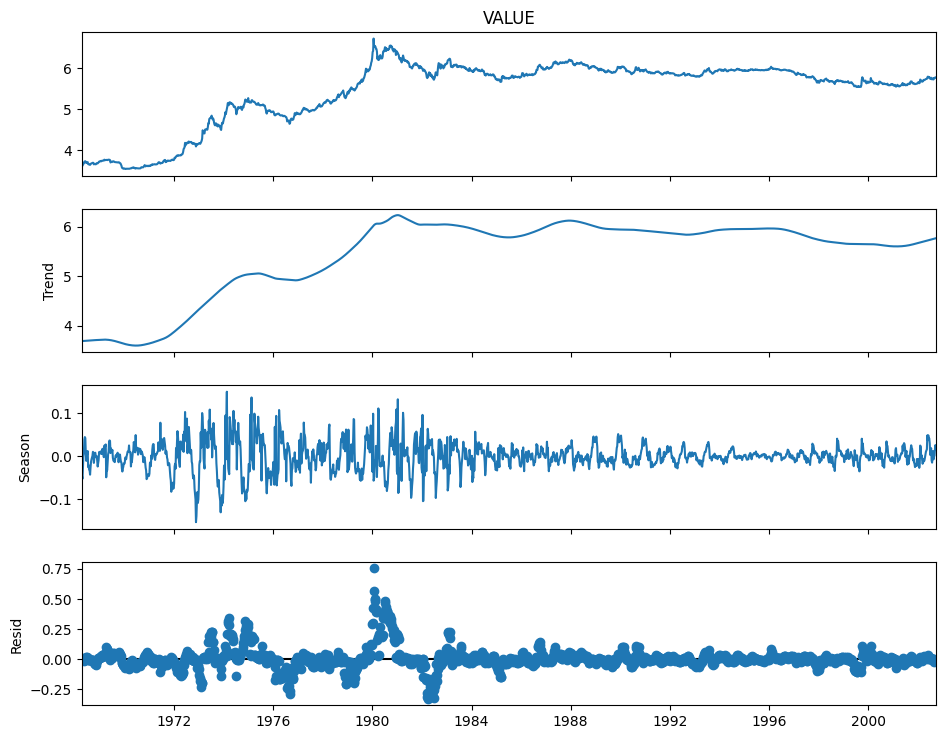

Força da tendência (F_tend) = 0.988 | Força da sazonalidade (F_saz) = 0.033


,tendencia_media,passos_no_ano,variacao_%
data,,,
1968,40.37,39,NaN
1969,39.96,52,-1.01
1970,36.89,52,-7.69
1971,41.82,53,13.38
1972,60.59,52,44.88
1973,95.86,52,58.21
1974,139.73,52,45.76
1975,152.69,52,9.28
1976,138.50,53,-9.29


In [5]:
def detectar_periodo_sazonal(serie, max_lag=60, candidatos=(7, 14, 30)):
    """Confere SEASONAL_PERIODS na série diferenciada (remove a tendência).

    Devolve um dicionário com o lag de maior ACF, o limite de 95% (±1,96/sqrt(n)) e a ACF
    nos candidatos. Só há evidência de sazonalidade se algum candidato superar o limite;
    o pico geral pode ser ruído (muitos lags testados).
    """
    dif = serie.diff().dropna()
    n = len(dif)
    valores = acf(dif, nlags=max_lag, fft=True)
    limite = 1.96 / np.sqrt(n)
    lag_pico = int(np.argmax(valores[2:]) + 2)          # ignora lags 0 e 1
    acf_cand = {c: float(valores[c]) for c in candidatos if c <= max_lag}
    return {'lag_pico': lag_pico, 'acf_pico': float(valores[lag_pico]), 'limite': float(limite),
            'acf_candidatos': acf_cand, 'evidencia': any(v > limite for v in acf_cand.values())}

# Diagnóstico exploratório SÓ no treino (não usa o teste para decidir o modelo)
y_treino = y.iloc[:n_train]
# Log apenas se a série for estritamente positiva; senão o diagnóstico usa a própria série
serie_diag = np.log(y_treino) if USE_LOG else y_treino
escala = 'log' if USE_LOG else 'original'
print(f'Escala do diagnóstico (T04/T05): {escala}')

res_acf = detectar_periodo_sazonal(serie_diag, max_lag=ACF_MAX_LAG, candidatos=ACF_CAND)
print(f"Limite 95%: ±{res_acf['limite']:.3f}")
print('ACF nos candidatos:', {k: round(v, 3) for k, v in res_acf['acf_candidatos'].items()})
print(f"Maior pico geral: lag {res_acf['lag_pico']} (ACF={res_acf['acf_pico']:.3f}) — sem interpretação sazonal")

if res_acf['evidencia'] and SEASONAL is None:
    print('ATENÇÃO: há evidência de sazonalidade, mas SEASONAL=None. Revise a configuração.')
elif not res_acf['evidencia']:
    print(f'Sem evidência de ciclo nos lags candidatos: coerente com SEASONAL={SEASONAL}.')
else:
    print(f'Evidência de ciclo nos lags candidatos: coerente com SEASONAL={SEASONAL}.')
print(f'SEASONAL_PERIODS={SEASONAL_PERIODS} (ciclo anual de 52 semanas), usado na STL e no grid do SARIMA.')

# Decomposição STL
stl_res = STL(serie_diag, period=SEASONAL_PERIODS, robust=True).fit()
fig = stl_res.plot()
fig.set_size_inches(10, 8)
plt.show()

# Força da tendência e da sazonalidade (Wang, Smith & Hyndman, 2006)
F_tend = max(0, 1 - stl_res.resid.var() / (stl_res.trend + stl_res.resid).var())
F_saz = max(0, 1 - stl_res.resid.var() / (stl_res.seasonal + stl_res.resid).var())
print(f'Força da tendência (F_tend) = {F_tend:.3f} | Força da sazonalidade (F_saz) = {F_saz:.3f}')

# Leitura numérica da tendência: alta / queda / estabilidade por ano (na escala da série)
tend_nivel = np.exp(stl_res.trend) if USE_LOG else stl_res.trend
g = tend_nivel.groupby(tend_nivel.index.year)
tend_anual = g.mean()
tabela_tend = pd.DataFrame({'tendencia_media': tend_anual, 'passos_no_ano': g.size()})
if USE_LOG:
    tabela_tend['variacao_%'] = tend_anual.pct_change() * 100
else:
    tabela_tend['variacao_abs'] = tend_anual.diff()   # série com zero/negativos: variação relativa não faz sentido
display(tabela_tend.round(2))


## T05 — Força da sazonalidade e resíduos

Cálculo da força da sazonalidade e análise do componente residual.

Força da sazonalidade: 0.033
Força da tendência:    0.988
Anos completos usados: [1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001] (n=33, amostra pequena)
Corr. amplitude × nível, escala log:     -0.39 (perto de 0 => amplitude relativa constante => compatível com multiplicativa)
Corr. amplitude × nível, escala original: 0.50 (esperado alto sob sazonalidade multiplicativa; F_saz ≈ 0 => conclusão fraca)

Resíduo STL (escala log):


,resid
count,1801.0000
mean,0.0048
std,0.0848
min,-0.3268
25%,-0.0207
50%,-0.0013
75%,0.0195
max,0.7519


Assimetria: 1.92 | Curtose em excesso: 11.97 (normal = 0)
Ljung-Box (autocorrelação do resíduo STL):


,lb_stat,lb_pvalue
13,10221.4701,0.0
26,12682.1111,0.0
52,13998.0403,0.0


Teste ARCH (variância não constante), p = 0.0000
Desvio padrão do resíduo por ano:


,std_resid
data,
1968,0.0157
1969,0.0333
1970,0.0375
1971,0.0223
1972,0.0536
1973,0.1103
1974,0.1126
1975,0.0606
1976,0.0803


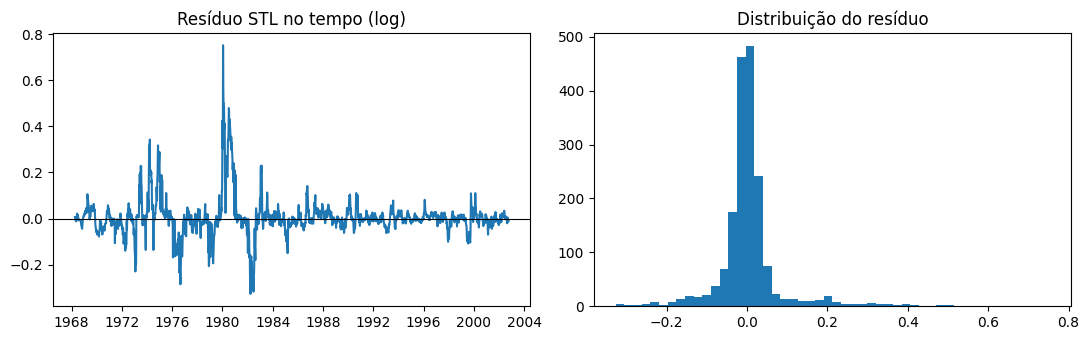

In [6]:
# T05 — Força da sazonalidade e resíduos
def forca(resid, componente):
    """Força (Hyndman): max(0, 1 - Var(R) / Var(componente + R)). Próxima de 1 => componente forte."""
    return max(0.0, 1 - np.var(resid) / np.var(componente + resid))

F_sazonal = forca(stl_res.resid, stl_res.seasonal)
F_tendencia = forca(stl_res.resid, stl_res.trend)
print(f'Força da sazonalidade: {F_sazonal:.3f}')
print(f'Força da tendência:    {F_tendencia:.3f}')

# Aditivo x multiplicativo. Em log, sazonalidade multiplicativa => amplitude (em log) constante.
LINHAS_POR_ANO = {'D': 365, 'h': 8760, 'W-FRI': 52}[FREQUENCY]
anos_completos = [a for a in stl_res.seasonal.index.year.unique()
                  if (stl_res.seasonal.index.year == a).sum() >= LINHAS_POR_ANO]
def amp_nivel(sazonal, tendencia):
    amp = sazonal.groupby(sazonal.index.year).agg(lambda s: s.max() - s.min())
    niv = tendencia.groupby(tendencia.index.year).mean()
    return amp, niv

escala = 'log' if USE_LOG else 'original'
amp_d, niv_d = amp_nivel(stl_res.seasonal, stl_res.trend)
print(f'Anos completos usados: {anos_completos} (n={len(anos_completos)}, amostra pequena)')
if USE_LOG:
    tend_p = np.exp(stl_res.trend)
    amp_p, niv_p = amp_nivel(tend_p * (np.exp(stl_res.seasonal) - 1), tend_p)
    print(f'Corr. amplitude × nível, escala log:     {amp_d.loc[anos_completos].corr(niv_d.loc[anos_completos]):.2f} '
          '(perto de 0 => amplitude relativa constante => compatível com multiplicativa)')
    print(f'Corr. amplitude × nível, escala original: {amp_p.loc[anos_completos].corr(niv_p.loc[anos_completos]):.2f} '
          '(esperado alto sob sazonalidade multiplicativa; F_saz ≈ 0 => conclusão fraca)')
else:
    print(f'Corr. amplitude × nível, escala {escala}: {amp_d.loc[anos_completos].corr(niv_d.loc[anos_completos]):.2f} '
          '(perto de 0 => amplitude relativa constante)')

# Componente residual (escala do diagnóstico)
r = stl_res.resid
print(f'\nResíduo STL (escala {escala}):')
display(r.describe().round(4).to_frame('resid'))
print(f'Assimetria: {stats.skew(r):.2f} | Curtose em excesso: {stats.kurtosis(r):.2f} (normal = 0)')
print('Ljung-Box (autocorrelação do resíduo STL):')
display(acorr_ljungbox(r, lags=list(LB_LAGS)).round(4))
print(f'Teste ARCH (variância não constante), p = {het_arch(r, nlags=7)[1]:.4f}')
print('Desvio padrão do resíduo por ano:')
display(r.groupby(r.index.year).std().round(4).to_frame('std_resid'))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(r)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_title(f'Resíduo STL no tempo ({escala})')
ax[1].hist(r, bins=50)
ax[1].set_title('Distribuição do resíduo')
plt.tight_layout()
plt.show()


# 3. Validação temporal

## T08 — Validação walk-forward

Protocolo walk-forward de janela expansiva. As origens partem do **corte treino/teste (75/25%)** e avançam de `ORIGIN_STEP` em `ORIGIN_STEP` semanas; cada janela de teste tem `HORIZON` semanas e cabe inteira no período de teste. O hold-out simples é a própria partição 75/25% (1.801 semanas de treino / 601 de teste).


In [7]:
# T08 — Validação walk-forward (janela expansiva)
def make_origins(n_obs, n_train, horizon, n_origins, step):
    """Tamanhos de treino (origens), a partir do corte treino/teste (75/25%).
    Cada janela de teste cabe dentro do período de teste."""
    origens = [n_train + k * step for k in range(n_origins)]
    assert origens[-1] + horizon <= n_obs, (
        f'As {n_origins} origens com passo {step} excedem a base; '
        f'máximo = {(n_obs - n_train - horizon) // step + 1}.')
    return origens


def walk_forward(serie, forecast_fn, origins, horizon, serie_avaliacao=None):
    """Para cada origem: ajusta só com o passado e prevê `horizon` passos à frente.
    `serie_avaliacao` (opcional) fornece o y_real com os NaN originais; os pontos não
    observados são mascarados nas métricas (a avaliação não imputa NaN)."""
    aval = serie if serie_avaliacao is None else serie_avaliacao
    partes = []
    for o in origins:
        treino, teste = serie.iloc[:o], serie.iloc[o:o + horizon]
        assert len(teste) == horizon, f'Janela incompleta na origem {o}.'
        prev = np.asarray(forecast_fn(treino, horizon))
        partes.append(pd.DataFrame({
            'origem': treino.index[-1], 'data': teste.index, 'h': np.arange(1, horizon + 1),
            'y_real': aval.iloc[o:o + horizon].values, 'y_prev': prev,
        }))
    return pd.concat(partes, ignore_index=True)


n_train = int(len(y) * TRAIN_FRAC)                      # 1801
ORIGINS = make_origins(len(y), n_train, HORIZON, N_ORIGINS, ORIGIN_STEP)
assert ORIGINS[0] >= 2 * SEASONAL_PERIODS, 'Treino da 1ª origem menor que 2 ciclos sazonais.'
# NaN de y_obs dentro das janelas de teste são esperados: a avaliação usa máscara
n_nan_janelas = int(y_obs.iloc[ORIGINS[0]:].isna().sum())
print(f'NaN do alvo dentro das janelas de teste: {n_nan_janelas} (mascarados nas métricas)')

# Hold-out simples = partição 75/25% da base (1.801 treino / 601 teste)
train, test = y.iloc[:n_train], y.iloc[n_train:]

display(pd.DataFrame([{
    'fold': i + 1, 'n_treino': o, 'treino_ate': y.index[o - 1].strftime(FMT_DATA),
    'teste_de': y.index[o].strftime(FMT_DATA), 'teste_ate': y.index[o + HORIZON - 1].strftime(FMT_DATA),
} for i, o in enumerate(ORIGINS)]))


NaN do alvo dentro das janelas de teste: 0 (mascarados nas métricas)


,fold,n_treino,treino_ate,teste_de,teste_ate
0,1,1801,2002-10-04,2002-10-11,2003-01-03
1,2,1814,2003-01-03,2003-01-10,2003-04-04
2,3,1827,2003-04-04,2003-04-11,2003-07-04
3,4,1840,2003-07-04,2003-07-11,2003-10-03
4,5,1853,2003-10-03,2003-10-10,2004-01-02
5,6,1866,2004-01-02,2004-01-09,2004-04-02
6,7,1879,2004-04-02,2004-04-09,2004-07-02
7,8,1892,2004-07-02,2004-07-09,2004-10-01
8,9,1905,2004-10-01,2004-10-08,2004-12-31
9,10,1918,2004-12-31,2005-01-07,2005-04-01


# 4. Modelagem Holt-Winters

## T09 — Holt-Winters

Modelo principal: **Holt com tendência aditiva amortecida e sem sazonalidade (sem evidência de ciclo anual no T04/T05). A família Holt-Winters completa (variantes aditiva e multiplicativa, período 52) e o SES são ajustados como comparação, junto com as referências ingênuas. Esta seção: (1) ajuste no treino e parâmetros α, β, γ e φ; (2) walk-forward de todos os modelos com as **mesmas origens**; (3) sensibilidade ao amortecimento; (4) SARIMA como referência (quando `RUN_SARIMA = True`).


In [8]:
def ajustar_hw(serie, trend=TREND, seasonal=SEASONAL, damped=DAMPED_TREND, damping_trend=None,
               seasonal_periods=SEASONAL_PERIODS, use_boxcox=USE_BOXCOX):
    """Ajusta um Holt-Winters com os padrões da configuração; qualquer argumento pode ser sobrescrito."""
    modelo = ExponentialSmoothing(
        serie, trend=trend, damped_trend=bool(damped and trend), seasonal=seasonal,
        seasonal_periods=seasonal_periods if seasonal else None,
        use_boxcox=use_boxcox, initialization_method=INITIALIZATION_METHOD)
    kw = {'optimized': OPTIMIZED}
    if damping_trend is not None:
        kw['damping_trend'] = damping_trend      # φ fixo (exercício de sensibilidade)
    return modelo.fit(**kw)


def parametros(fit):
    """Parâmetros de suavização estimados: α (nível), β (tendência), γ (sazonal) e φ (amortecimento)."""
    p = fit.params
    return {'alpha': p.get('smoothing_level'), 'beta': p.get('smoothing_trend'),
            'gamma': p.get('smoothing_seasonal'), 'phi': p.get('damping_trend')}


# Ajustes no treino (hold-out 75/25%). Mesmo treino de 1.801 semanas para todos os modelos
_hw = lambda **kw: ExponentialSmoothing(train, initialization_method=INITIALIZATION_METHOD, **kw).fit()
_positivo = bool((train > 0).all())      # variantes 'mul' exigem série estritamente positiva
fits_holdout = {
    'SES (sem tend./saz.)': _hw(),
    'HW aditivo': _hw(trend='add', seasonal='add', seasonal_periods=SEASONAL_PERIODS),
}
if _positivo:
    fits_holdout['HW multiplicativo'] = _hw(trend='add', seasonal='mul', seasonal_periods=SEASONAL_PERIODS)
    fits_holdout['HW multiplicativo amortecido'] = _hw(trend='add', damped_trend=True,
                                                      seasonal='mul', seasonal_periods=SEASONAL_PERIODS)
else:
    print('Série com zeros/negativos: variantes multiplicativas substituídas por HW aditivo amortecido.')
    fits_holdout['HW aditivo amortecido'] = _hw(trend='add', damped_trend=True,
                                               seasonal='add', seasonal_periods=SEASONAL_PERIODS)
assert all(len(f.resid) == n_train for f in fits_holdout.values()), (
    'fits_holdout foi ajustado com outra janela de treino.')
fit_cfg = ajustar_hw(train)             # modelo configurado (TREND / SEASONAL / DAMPED_TREND)

tabela_param = pd.DataFrame({
    nome: {**parametros(f), 'AIC': f.aic}
    for nome, f in {**fits_holdout, 'Holt amortecido (configurado)': fit_cfg}.items()
}).T
print('Parâmetros estimados no treino (α≈1 => o nível acompanha quase só o último valor):')
display(tabela_param.round(4))


Parâmetros estimados no treino (α≈1 => o nível acompanha quase só o último valor):


,alpha,beta,gamma,phi,AIC
SES (sem tend./saz.),0.9200,NaN,NaN,NaN,8573.9440
HW aditivo,0.9199,0.0000,0.0025,NaN,8682.3356
HW multiplicativo,0.9232,0.0000,0.0378,NaN,8713.9840
HW multiplicativo amortecido,0.8556,0.0984,0.0369,0.800,8705.4020
Holt amortecido (configurado),0.9199,0.0000,NaN,0.995,8579.7005


In [9]:
# Walk-forward de todos os modelos, com as MESMAS origens e horizonte
def hw_forecaster(**kw):
    def f(treino, h):
        return ExponentialSmoothing(treino, initialization_method=INITIALIZATION_METHOD, **kw).fit().forecast(h)
    return f

def naive_forecaster(treino, h):
    return np.repeat(treino.iloc[-1], h)                    # repete o último valor

def naive_drift_forecaster(treino, h):
    deriva = (treino.iloc[-1] - treino.iloc[0]) / (len(treino) - 1)   # variação média por passo
    return treino.iloc[-1] + deriva * np.arange(1, h + 1)

modelos = {
    'SES (sem tend./saz.)': hw_forecaster(),
    'HW aditivo': hw_forecaster(trend='add', seasonal='add', seasonal_periods=SEASONAL_PERIODS),
    'Holt amortecido (sem saz.)': hw_forecaster(trend='add', damped_trend=True),
    'Ingênuo': naive_forecaster,
    'Ingênuo c/ deriva': naive_drift_forecaster,
}
if _positivo:      # definido na célula anterior; 'mul' exige série estritamente positiva
    modelos['HW multiplicativo'] = hw_forecaster(trend='add', seasonal='mul', seasonal_periods=SEASONAL_PERIODS)
    modelos['HW multiplicativo amortecido'] = hw_forecaster(trend='add', damped_trend=True,
                                                            seasonal='mul', seasonal_periods=SEASONAL_PERIODS)
else:
    modelos['HW aditivo amortecido'] = hw_forecaster(trend='add', damped_trend=True,
                                                     seasonal='add', seasonal_periods=SEASONAL_PERIODS)

wf_resultados = {nome: walk_forward(y, f, ORIGINS, HORIZON, y_obs) for nome, f in modelos.items()}

# Alarmes: mesmas origens e sem NaN nas previsões (y_real pode ter NaN: pontos não observados)
_ref = set(next(iter(wf_resultados.values()))['origem'])
assert len(_ref) == N_ORIGINS
assert all(set(d['origem']) == _ref for d in wf_resultados.values()), 'Modelos com origens diferentes.'
assert all(d['y_prev'].notna().all() for d in wf_resultados.values()), 'Há NaN nas previsões.'
n_obs_min = min(int(d['y_real'].notna().sum()) for d in wf_resultados.values())
print(f'{len(_ref)} folds | origens de {min(_ref):{FMT_DATA}} a {max(_ref):{FMT_DATA}} | '
      f'{len(wf_resultados)} modelos | menor nº de pontos observados por fold: {n_obs_min}')


46 folds | origens de 2002-10-04 a 2013-12-20 | 7 modelos | menor nº de pontos observados por fold: 598


### Sensibilidade da tendência amortecida (φ)

Sem amortecimento a tendência é somada linearmente e a previsão diverge com o horizonte. Com ``damped_trend=True`` cada passo
futuro da tendência é multiplicado por uma potência de φ (0 < φ < 1). Compara-se φ estimado por MLE com φ fixo, em um horizonte longo.

,phi,valor_final,variacao_%_vs_sem_damping,AIC,RMSE,MAE,MAPE_%
0,sem damping,331.73,0.00,8579.45,27.17,22.52,6.27
1,MLE (0.9950),321.54,-3.07,8579.70,32.46,27.25,7.59
2,0.99,321.54,-3.07,8579.96,32.46,27.25,7.59
3,0.97,324.11,-2.30,8579.41,30.85,25.72,7.16
4,0.95,323.18,-2.58,8579.25,31.35,26.18,7.28
5,0.9,322.62,-2.75,8578.57,31.64,26.45,7.36
6,0.8,323.10,-2.60,8571.07,31.22,26.05,7.25
7,0.7,322.63,-2.74,8562.42,31.58,26.41,7.35
8,ingênuo,321.65,-3.04,NaN,32.37,27.17,7.56


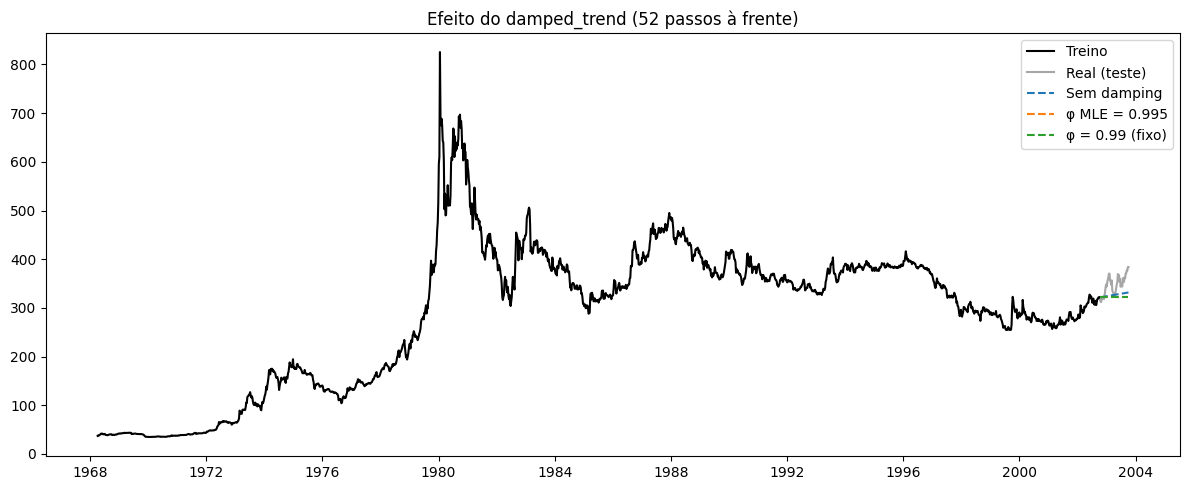

In [10]:
# Efeito do damped_trend — só avaliação; φ NÃO é escolhido olhando o teste
real_h = y_obs.iloc[n_train:n_train + LONG_HORIZON]
assert len(real_h) == LONG_HORIZON, 'LONG_HORIZON excede o tamanho do teste.'
mascara = real_h.notna().values          # pontos não observados ficam fora das métricas
assert mascara.any(), 'Janela do horizonte longo sem nenhum ponto observado.'

def metricas(fc):
    e = (real_h.values - fc.values)[mascara]
    y_abs = np.abs(real_h.values[mascara])
    y_abs = np.where(y_abs > 0, y_abs, np.nan)   # MAPE não está definido em y = 0
    return {'RMSE': np.sqrt((e ** 2).mean()), 'MAE': np.abs(e).mean(),
            'MAPE_%': np.nanmean(np.abs(e) / y_abs) * 100}

sem_damping = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=False)
mle = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True)
phi_mle = parametros(mle)['phi']

fc_base = sem_damping.forecast(LONG_HORIZON)
fc_mle = mle.forecast(LONG_HORIZON)
valor_base = fc_base.iloc[-1]
fc_naive = pd.Series(np.repeat(train.iloc[-1], LONG_HORIZON), index=fc_base.index)

linhas = [
    {'phi': 'sem damping', 'valor_final': valor_base, 'variacao_%_vs_sem_damping': 0.0,
     'AIC': sem_damping.aic, **metricas(fc_base)},
    {'phi': f'MLE ({phi_mle:.4f})', 'valor_final': fc_mle.iloc[-1],
     'variacao_%_vs_sem_damping': (fc_mle.iloc[-1] / valor_base - 1) * 100,
     'AIC': mle.aic, **metricas(fc_mle)},
]
fc_fixos = {}
for phi in DAMPING_GRID:
    fit = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True, damping_trend=phi)
    fc_fixos[phi] = fit.forecast(LONG_HORIZON)
    linhas.append({'phi': phi, 'valor_final': fc_fixos[phi].iloc[-1],
                   'variacao_%_vs_sem_damping': (fc_fixos[phi].iloc[-1] / valor_base - 1) * 100,
                   'AIC': fit.aic, **metricas(fc_fixos[phi])})
linhas.append({'phi': 'ingênuo', 'valor_final': fc_naive.iloc[-1],
               'variacao_%_vs_sem_damping': (fc_naive.iloc[-1] / valor_base - 1) * 100,
               'AIC': np.nan, **metricas(fc_naive)})
display(pd.DataFrame(linhas).round(2))

phi_plot = 0.99 if 0.99 in fc_fixos else DAMPING_GRID[0]   # distinto do MLE no gráfico
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, color='black', label='Treino')
plt.plot(real_h.index, real_h.values, color='gray', alpha=0.7, label='Real (teste)')
plt.plot(fc_base.index, fc_base.values, ls='--', label='Sem damping')
plt.plot(fc_mle.index, fc_mle.values, ls='--', label=f'φ MLE = {phi_mle:.3f}')
plt.plot(fc_fixos[phi_plot].index, fc_fixos[phi_plot].values, ls='--', label=f'φ = {phi_plot} (fixo)')
plt.legend()
plt.title(f'Efeito do damped_trend ({LONG_HORIZON} passos à frente)')
plt.tight_layout()
plt.show()


### Modelo de referência — SARIMA (grid search)

Grid reduzido e justificado pela série: **d = 1** (o ADF indica raiz unitária no nível e estacionariedade na primeira diferença), **D = 0** (o ciclo sazonal é tratado pelo próprio Holt-Winters), p, q ≈ 0–2 e P, Q ≈ 0–1 com m = ``SEASONAL_PERIODS``, mais a opção sem componente sazonal.
Para não vazar informação do futuro, o grid é feito só com o treino da **primeira origem** (o treino original de 1.801 semanas) e a ordem escolhida fica congelada
para todos os folds (o MAE do teste não entra na escolha).

> `RUN_SARIMA = True` nesta base: a série tem apenas 2.402 semanas e o grid com m = 52 é viável.

> **Atenção ao critério (AIC):** o `aic` do `SARIMAX` **não é comparável** entre modelos com componentes sazonais diferentes, porque cada um descarta um número
> diferente de observações iniciais no cálculo da verossimilhança (`loglikelihood_burn` cresce com a ordem sazonal). Isso fazia um termo sazonal
> com coeficiente ≈ 0 parecer ganhar ~109 pontos de AIC no caso diário. Aqui o AIC é recalculado descartando as **mesmas** `2×m` observações
> iniciais de todos os modelos (`AIC_comparavel`).


In [11]:
if RUN_SARIMA:
    treino_grid = y.iloc[:ORIGINS[0]]          # só o treino original (1.801 semanas)

    # d=1 e D=0 justificados por testes no treino
    print(f'ADF (H0: raiz unitária) — nível: p={adfuller(treino_grid)[1]:.4f} | '
          f'1ª diferença: p={adfuller(treino_grid.diff().dropna())[1]:.4f}')
    pdq = [(p, 1, q) for p, q in itertools.product(range(3), range(3))]
    # sem sazonalidade (0,0,0,0) + variantes sazonais (m = SEASONAL_PERIODS), para comparar
    sazonal_pdq = [(0, 0, 0, 0)] + [(P, 0, Q, SEASONAL_PERIODS)
                                    for P, Q in itertools.product(range(2), range(2)) if (P, Q) != (0, 0)]

    BURN_COMUM = 2 * SEASONAL_PERIODS          # mesmas observações iniciais descartadas em todos os modelos
    resultados, falhas = [], 0
    for order in pdq:
        for seasonal_order in sazonal_pdq:
            try:
                res = SARIMAX(treino_grid, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                ll = np.nansum(res.llf_obs[BURN_COMUM:])
                resultados.append({'order': order, 'seasonal_order': seasonal_order,
                                   'AIC_comparavel': -2 * ll + 2 * len(res.params),
                                   'AIC_statsmodels': res.aic, 'burn': res.model.loglikelihood_burn})
            except Exception:
                falhas += 1
    print(f'{len(resultados)} modelos ajustados, {falhas} falhas')

    grid_sarima = pd.DataFrame(resultados).sort_values('AIC_comparavel').reset_index(drop=True)
    assert grid_sarima['burn'].max() <= BURN_COMUM, 'BURN_COMUM menor que o burn de algum modelo.'
    display(grid_sarima.head(10).round(1))
    melhor = grid_sarima.iloc[0]
    print(f"Escolhido: order={melhor['order']}, seasonal_order={melhor['seasonal_order']}")

    def sarima_forecaster(treino, h):
        return SARIMAX(treino, order=melhor['order'], seasonal_order=melhor['seasonal_order'],
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False).forecast(h)

    wf_resultados['SARIMA (grid AIC)'] = walk_forward(y, sarima_forecaster, ORIGINS, HORIZON, y_obs)


ADF (H0: raiz unitária) — nível: p=0.2374 | 1ª diferença: p=0.0000
36 modelos ajustados, 0 falhas


,order,seasonal_order,AIC_comparavel,AIC_statsmodels,burn
0,"(2, 1, 2)","(0, 0, 1, 52)",12974.6,13292.3,56
1,"(2, 1, 2)","(1, 0, 0, 52)",12974.6,13298.9,55
2,"(2, 1, 2)","(0, 0, 0, 0)",12974.8,13633.5,4
3,"(2, 1, 2)","(1, 0, 1, 52)",12976.6,13294.3,56
4,"(1, 1, 2)","(0, 0, 1, 52)",12976.7,13294.2,56
5,"(1, 1, 2)","(1, 0, 0, 52)",12976.7,13307.4,54
6,"(1, 1, 2)","(0, 0, 0, 0)",12977.0,13635.6,4
7,"(0, 1, 2)","(0, 0, 1, 52)",12977.5,13295.1,56
8,"(0, 1, 2)","(1, 0, 0, 52)",12977.6,13315.0,53
9,"(0, 1, 2)","(0, 0, 0, 0)",12977.8,13636.7,4


Escolhido: order=(2, 1, 2), seasonal_order=(0, 0, 1, 52)


# 5. Avaliação

## T16 — Comparação por MAE

Consolidação do MAE fora da amostra por base e modelo, incluindo número de vitórias e posição média.

MAE por fold:


,SES (sem tend./saz.),HW aditivo,Holt amortecido (sem saz.),Ingênuo,Ingênuo c/ deriva,HW multiplicativo,HW multiplicativo amortecido,SARIMA (grid AIC)
fold 1 (origem 2002-10-04),9.44,9.03,9.44,9.45,9.10,8.47,7.14,9.42
fold 2 (origem 2003-01-03),14.45,14.61,14.44,14.56,14.57,14.60,13.99,14.44
fold 3 (origem 2003-04-04),25.30,23.26,25.30,25.88,24.78,17.04,22.60,25.07
fold 4 (origem 2003-07-04),16.30,17.09,16.31,15.96,14.84,22.12,25.07,16.54
fold 5 (origem 2003-10-03),14.56,14.22,14.56,14.54,13.48,16.59,13.16,14.16
fold 6 (origem 2004-01-02),10.23,10.16,10.23,10.43,11.06,9.74,11.41,10.56
fold 7 (origem 2004-04-02),33.15,35.21,33.15,33.87,35.32,45.44,48.48,33.86
fold 8 (origem 2004-07-02),9.12,9.70,9.12,9.28,8.48,14.81,15.18,8.31
fold 9 (origem 2004-10-01),17.01,16.79,17.01,16.37,15.06,21.21,21.68,15.61
fold 10 (origem 2004-12-31),12.05,12.38,12.05,11.79,12.93,13.35,12.68,12.94


Resumo (46 folds):


,base,MAE_medio,MAE_ultimo_fold,vitorias,posicao_media,MAE_vs_ingenuo_%,folds_melhor_que_ingenuo
Ingênuo c/ deriva,base-tratada-5.xlsx,47.56,85.77,12,3.33,-1.33,32
Holt amortecido (sem saz.),base-tratada-5.xlsx,47.88,96.68,4,3.89,-0.66,27
HW aditivo,base-tratada-5.xlsx,48.01,85.74,6,4.33,-0.38,24
SARIMA (grid AIC),base-tratada-5.xlsx,48.28,88.77,3,4.39,0.17,23
SES (sem tend./saz.),base-tratada-5.xlsx,48.09,88.13,2,4.48,-0.22,25
Ingênuo,base-tratada-5.xlsx,48.20,89.17,4,4.48,0.00,0
HW multiplicativo amortecido,base-tratada-5.xlsx,52.55,92.96,9,5.41,9.03,16
HW multiplicativo,base-tratada-5.xlsx,52.24,86.49,6,5.70,8.39,13


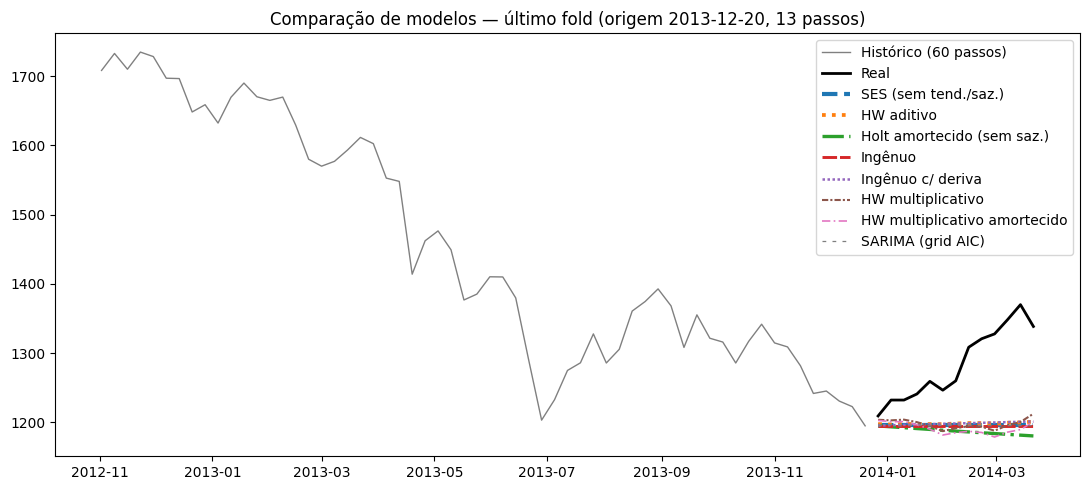

In [12]:
# T16 — Comparação por MAE (fora da amostra, walk-forward; NaN de y_real mascarados)
tabela_mae = pd.DataFrame({
    nome: {origem: np.nanmean(np.abs(d['y_real'] - d['y_prev'])) for origem, d in df_wf.groupby('origem')}
    for nome, df_wf in wf_resultados.items()
})
assert not tabela_mae.isna().any().any(), (
    'Há NaN: fold sem nenhum ponto observado ou modelos com origens diferentes — regenere o wf_resultados.')
origens_idx = tabela_mae.index                                   # guarda as datas reais
tabela_mae.index = [f'fold {i + 1} (origem {o:{FMT_DATA}})' for i, o in enumerate(origens_idx)]
print('MAE por fold:')
display(tabela_mae.round(2))

posicoes = tabela_mae.rank(axis=1, method='min')                 # 1 = melhor no fold
resumo = pd.DataFrame({
    'base': DATA_FILENAME,
    'MAE_medio': tabela_mae.mean(),
    'MAE_ultimo_fold': tabela_mae.iloc[-1],
    'vitorias': (posicoes == 1).sum(),
    'posicao_media': posicoes.mean(),
})
REF = 'Ingênuo'                                                  # ajuste ao nome usado em wf_resultados
assert REF in tabela_mae.columns, f'Inclua {REF} em wf_resultados (referência da comparação).'
resumo['MAE_vs_ingenuo_%'] = (resumo['MAE_medio'] / tabela_mae[REF].mean() - 1) * 100
resumo['folds_melhor_que_ingenuo'] = tabela_mae.lt(tabela_mae[REF], axis=0).sum()
resumo = resumo.sort_values(['posicao_media', 'MAE_medio'])
print(f'Resumo ({len(tabela_mae)} folds):')
display(resumo.round(2))

# Gráfico do último fold: real e previsões na MESMA janela (HORIZON passos) + 60 passos de contexto
ultimo = origens_idx.max()
real_ult = next(iter(wf_resultados.values())).query('origem == @ultimo')
plt.figure(figsize=(11, 5))
plt.plot(y.loc[:ultimo].iloc[-60:].index, y.loc[:ultimo].iloc[-60:].values, color='gray', lw=1,
         label='Histórico (60 passos)')
plt.plot(real_ult['data'], real_ult['y_real'], color='black', lw=2, label='Real')
estilos = ['--', ':', '-.', (0, (5, 1)), (0, (1, 1)), (0, (3, 1, 1, 1)), (0, (5, 2, 1, 2)), (0, (3, 5))]
for i, (nome, df_wf) in enumerate(wf_resultados.items()):   # estilos/espessuras distintos: as curvas planas se sobrepõem
    d = df_wf[df_wf['origem'] == ultimo]
    plt.plot(d['data'], d['y_prev'], ls=estilos[i % len(estilos)], lw=3 - 0.3 * i, label=nome)
plt.legend()
plt.title(f'Comparação de modelos — último fold (origem {ultimo:{FMT_DATA}}, {HORIZON} passos)')
plt.tight_layout()
plt.show()


## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

Modelo configurado: trend=add, seasonal=None, damped=True | log=True | n resíduos = 1801


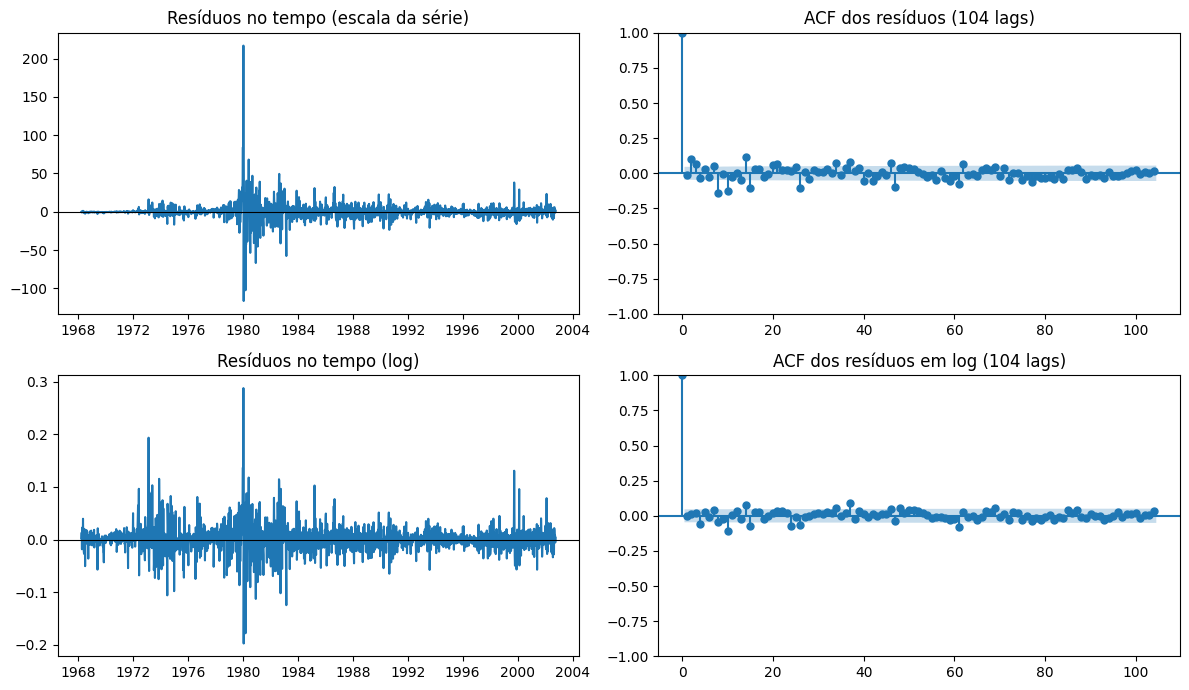

p-valores do teste de Ljung-Box:


,lag 13,lag 26,lag 52
SES (sem tend./saz.),0.0000,0.0,0.0
HW aditivo,0.0000,0.0,0.0
HW multiplicativo,0.0000,0.0,0.0
HW multiplicativo amortecido,0.0000,0.0,0.0
Holt amortecido (configurado),0.0000,0.0,0.0
Holt amortecido (log),0.0002,0.0,0.0


Desvio padrão dos resíduos por ano:


,std_serie,std_log
data,,
1968,0.6857,0.0166
1969,0.5285,0.0129
1970,0.2975,0.0080
1971,0.4946,0.0121
1972,1.5222,0.0253
1973,4.8068,0.0497
1974,6.3604,0.0406
1975,4.0512,0.0254
1976,3.2651,0.0264


In [13]:
# T17 — Diagnóstico dos resíduos (granularidade semanal (W-FRI, sextas-feiras))
# Garante que é o treino semanal (W-FRI) (1801 passos) e não uma série de outra execução
assert len(train) == n_train and pd.infer_freq(train.index) == FREQUENCY, (
    'train não é a série configurada: rode o notebook inteiro na ordem (Restart & Run All).')

# Modelo configurado, na escala da série[; e em log quando toda a série é estritamente positiva]
resid = fit_cfg.resid                  # modelo configurado, ajustado na T09 (TREND / SEASONAL / DAMPED_TREND)
modelos_lb = {**fits_holdout, 'Holt amortecido (configurado)': fit_cfg}
if USE_LOG:
    fit_log = ExponentialSmoothing(np.log(train), trend=TREND, seasonal=SEASONAL,
                                   seasonal_periods=SEASONAL_PERIODS if SEASONAL else None,
                                   damped_trend=DAMPED_TREND,
                                   initialization_method=INITIALIZATION_METHOD).fit(optimized=OPTIMIZED)
    resid_log = fit_log.resid
    modelos_lb['Holt amortecido (log)'] = fit_log
else:
    resid_log = None                   # log inválido (zeros/negativos): resíduos só na escala original
print(f'Modelo configurado: trend={TREND}, seasonal={SEASONAL}, damped={DAMPED_TREND} | '
      f'log={USE_LOG} | n resíduos = {len(resid)}')

LAGS_ACF = max(4, min(2 * SEASONAL_PERIODS, len(resid) // 3))
n_linhas = 2 if USE_LOG else 1
fig, ax = plt.subplots(n_linhas, 2, figsize=(12, 3.5 * n_linhas))
ax = np.atleast_2d(ax)

ax[0, 0].plot(resid)
ax[0, 0].axhline(0, color='k', lw=0.8)
ax[0, 0].set_title('Resíduos no tempo (escala da série)')
plot_acf(resid, lags=LAGS_ACF, ax=ax[0, 1])
ax[0, 1].set_title(f'ACF dos resíduos ({LAGS_ACF} lags)')
if USE_LOG:
    ax[1, 0].plot(resid_log)
    ax[1, 0].axhline(0, color='k', lw=0.8)
    ax[1, 0].set_title('Resíduos no tempo (log)')
    plot_acf(resid_log, lags=LAGS_ACF, ax=ax[1, 1])
    ax[1, 1].set_title(f'ACF dos resíduos em log ({LAGS_ACF} lags)')
plt.tight_layout()
plt.show()

# Ljung-Box (H0: resíduos sem autocorrelação; p < 0.05 => rejeita H0). Lags na unidade da base:
LAGS = [l for l in LB_LAGS if l <= len(resid) // 3]
tabela_lb = pd.DataFrame({
    nome: acorr_ljungbox(f.resid, lags=LAGS, return_df=True)['lb_pvalue']
    for nome, f in modelos_lb.items()
}).T
tabela_lb.columns = [f'lag {l}' for l in LAGS]
print('p-valores do teste de Ljung-Box:')
display(tabela_lb.round(4))

# A variância dos resíduos é constante ao longo do tempo?
print('Desvio padrão dos resíduos por ano:')
_cols = {'std_serie': resid.groupby(resid.index.year).std()}
if USE_LOG:
    _cols['std_log'] = resid_log.groupby(resid_log.index.year).std()
display(pd.DataFrame(_cols).round(4))


## Contexto das conclusões: estatísticas de treino e teste

O teste pode conter valores que o treino nunca viu (e, nas bases com NaN no alvo, pontos mascarados): contexto para interpretar os erros de previsão.


In [14]:
# O teste pode conter valores fora da faixa do treino: contexto para interpretar os erros de previsão
display(pd.DataFrame({'treino': train.describe(), 'teste': y_obs.iloc[n_train:].describe()}).round(0))


,treino,teste
count,1801.0,601.0
mean,286.0,927.0
std,144.0,463.0
min,35.0,312.0
25%,162.0,447.0
50%,322.0,873.0
75%,385.0,1322.0
max,826.0,1880.0


## Conclusões e limitações

> **Antes do commit:** os itens abaixo são um roteiro de interpretação — rode com `Restart & Run All` e complete com os números das saídas (T04/T05, T09, T16 e T17). O notebook do grupo 1 mostra o modelo de redação com valores preenchidos.

1. **Sazonalidade.** Registrar a ACF dos lags candidatos, o limite ±1,96/√n, `F_sazonal` e `F_tend` da STL (ciclo anual de 52 semanas) e dizer se o modelo principal é sustentado pelo diagnóstico.
2. **Parâmetros.** Reportar α, β, γ e φ do modelo configurado, o AIC relativo entre as variantes do T09 e o que isso implica (α ≈ 1 => o nível acompanha quase só o último valor; β ≈ 0 => tendência estável).
3. **Tendência amortecida.** Comparar a previsão sem damping, com φ MLE e com φ fixo no horizonte longo (52 semanas = 1 ano) e as métricas no teste (RMSE/MAE/MAPE).
4. **Walk-forward (46 folds, 13 passos).** Dizer se alguma variante Holt-Winters vence o ingênuo de forma consistente (vitórias por fold e MAE relativo, tabela do T16). Série de preço de ouro semanal: próxima de um passeio aleatório — esperam-se poucos ganhos sobre repetir o último valor.
5. **Resíduos.** Ljung-Box nos lags 13, 26 e 52 semanas (trimestre, meio ano e ano), distribuição e estabilidade de variância por ano; dizer se os resíduos são compatíveis com ruído branco e se intervalos normais de previsão são confiáveis.
6. **Limitações.**
   - **NaN no teste:** o alvo não tem NaN (treino e teste 100% observados); as métricas mascaram esses pontos (contagem na carga e no T08).
   - **Interpolação:** os NaN internos são interpolados **somente para ajustar** os modelos; a avaliação usa `y_obs`.
   - **Escala:** **Log:** aplicado (ouro > 0) em T04/T05/T17.
   - **Parâmetros de projeto:** horizonte de 13 passos, `N_ORIGINS = 46` e `LONG_HORIZON = 52` são decisões a confirmar no enunciado.
   - **Significância:** não foi aplicado teste formal de comparação de previsões (por exemplo, Diebold-Mariano); diferenças pequenas no MAE não devem ser tratadas como significativas.


# Checklist antes do commit

- [ ] Configuração e versão da execução atualizadas.
- [ ] Separação temporal e horizonte documentados.
- [ ] Transformadores ajustados somente com dados de treino.
- [ ] Hiperparâmetros congelados antes do teste final.
- [ ] Métricas calculadas com previsões fora da amostra.
- [ ] Artefatos essenciais salvos por tarefa.
- [ ] Saídas excessivas e células temporárias removidas.